Notebook 01: Data Cleaning & Exploratory Data Analysis
Goal: Fetch, clean, and explore 1-hour BTC/USDT price data. This notebook prepares the foundational dataset for all subsequent feature engineering and modeling.

Part 1: Setup & Data Ingestion
Here we set up our environment, import libraries, and define our data fetching function.

In [51]:
# --- Cell 1: Imports & Environment Setup ---
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from binance.client import Client
import mplfinance as mpf

# Set a nice style for our plots
sns.set_style('whitegrid')

print("Setup Complete. Libraries imported.")


Setup Complete. Libraries imported.


In [52]:
# --- Cell 2: Data Fetching Function ---
def fetch_crypto_data(symbol, start_date, interval=Client.KLINE_INTERVAL_1HOUR):
    """
    Fetches historical OHLCV data from Binance and returns it as a clean DataFrame.
    """
    print(f"Fetching {interval} data for {symbol} starting from {start_date}...")
    client = Client()
    klines = client.get_historical_klines(symbol=symbol, interval=interval, start_str=start_date)
    print(f"Found {len(klines)} records.")
    
    columns = [
        'Open Time', 'Open', 'High', 'Low', 'Close', 'Volume', 
        'Close Time', 'Quote Asset Volume', 'Number of Trades', 
        'Taker Buy Base Asset Volume', 'Taker Buy Quote Asset Volume', 'Ignore'
    ]
    df = pd.DataFrame(klines, columns=columns)
    
    df['Date'] = pd.to_datetime(df['Open Time'], unit='ms')
    numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
    df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    df.set_index('Date', inplace=True)
    
    print("Data successfully cleaned and converted to DataFrame.")
    return df

In [ ]:
# --- Cell 3: Execute Data Fetch ---
symbol_to_fetch = 'BTCUSDT'
start_date_str = '1 Jan, 2022' # Let's get a nice long history

raw_df = fetch_crypto_data(symbol=symbol_to_fetch, start_date=start_date_str)
display(raw_df.head())


Part 2: Initial Data Cleaning & Validation
Here we perform a basic health check on our data and take our first detailed look at the price action.


--- Data Types and Info ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19248 entries, 2024-01-01 00:00:00 to 2026-03-12 23:00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    19248 non-null  float64
 1   High    19248 non-null  float64
 2   Low     19248 non-null  float64
 3   Close   19248 non-null  float64
 4   Volume  19248 non-null  float64
dtypes: float64(5)
memory usage: 902.2 KB

--- Missing Values Check ---
✅ Excellent! No missing values found.

Generating Candlestick Chart for the last 15 days...


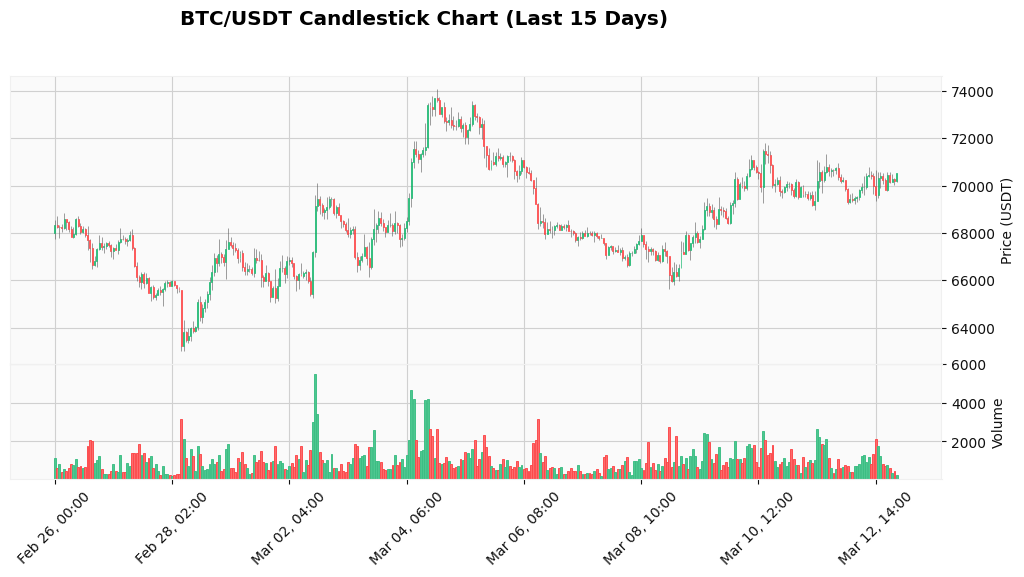

In [53]:
# --- Cell 4: Basic Inspection ---
print("\n--- Data Types and Info ---")
raw_df.info()

print("\n--- Missing Values Check ---")
if raw_df.isnull().sum().sum() == 0:
    print("✅ Excellent! No missing values found.")
else:
    print("Warning: Missing values detected.")
    print(raw_df.isnull().sum())
# --- Cell 5: Visual Validation with Candlestick Chart ---
print("\nGenerating Candlestick Chart for the last 15 days...")
recent_data = raw_df.last('15D') 

mpf.plot(
    recent_data, 
    type='candle', 
    style='yahoo',
    title='BTC/USDT Candlestick Chart (Last 15 Days)',
    ylabel='Price (USDT)',
    volume=True,
    figratio=(18, 8)
)

Part 3: Exploratory Data Analysis (EDA)
Now we dive deeper, exploring the statistical properties of our data to uncover patterns.

In [54]:
# --- Cell 6: Calculate Hourly Returns ---
# We calculate this once here, as it's used in many subsequent plots.
returns = raw_df['Close'].pct_change().dropna()
print("Hourly returns calculated and ready for analysis.")

Hourly returns calculated and ready for analysis.


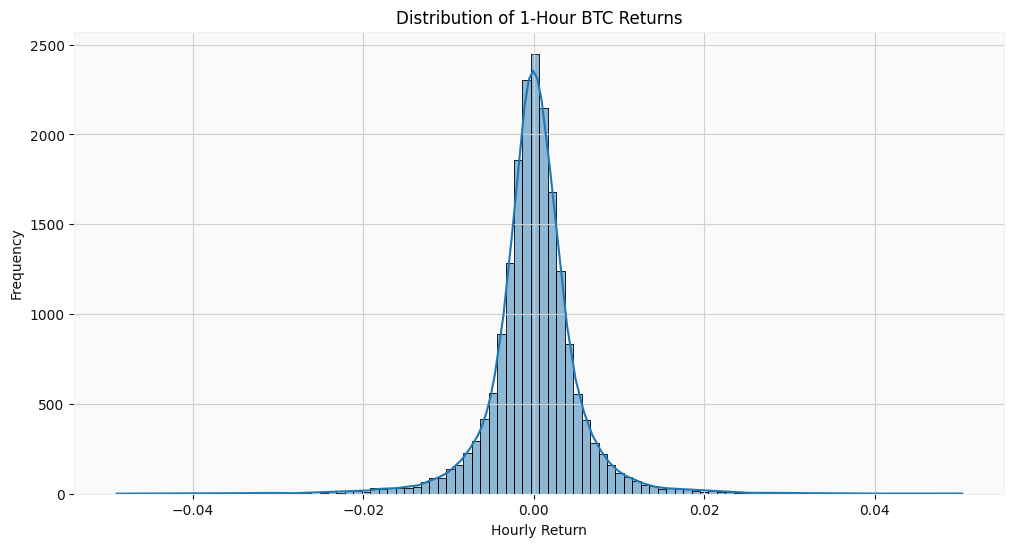


--- Key Statistics for Hourly Returns ---
count    19247.000000
mean         0.000040
std          0.005248
min         -0.048956
25%         -0.002126
50%          0.000040
75%          0.002314
max          0.050270
Name: Close, dtype: float64


In [55]:
# --- Cell 7: Distribution of Hourly Returns ---
plt.figure(figsize=(12, 6))
sns.histplot(returns, bins=100, kde=True)
plt.title('Distribution of 1-Hour BTC Returns')
plt.xlabel('Hourly Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

print("\n--- Key Statistics for Hourly Returns ---")
print(returns.describe())

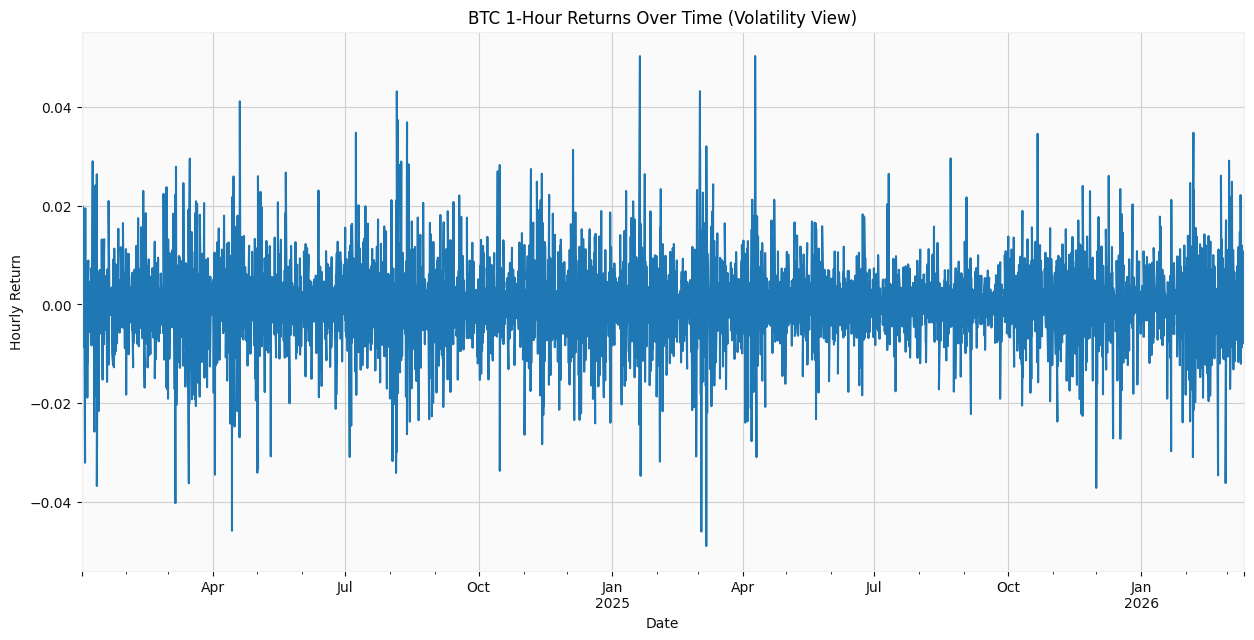

In [56]:
# --- Cell 8: Volatility Over Time ---
plt.figure(figsize=(15, 7))
returns.plot(title='BTC 1-Hour Returns Over Time (Volatility View)')
plt.xlabel('Date')
plt.ylabel('Hourly Return')
plt.grid(True)
plt.show()

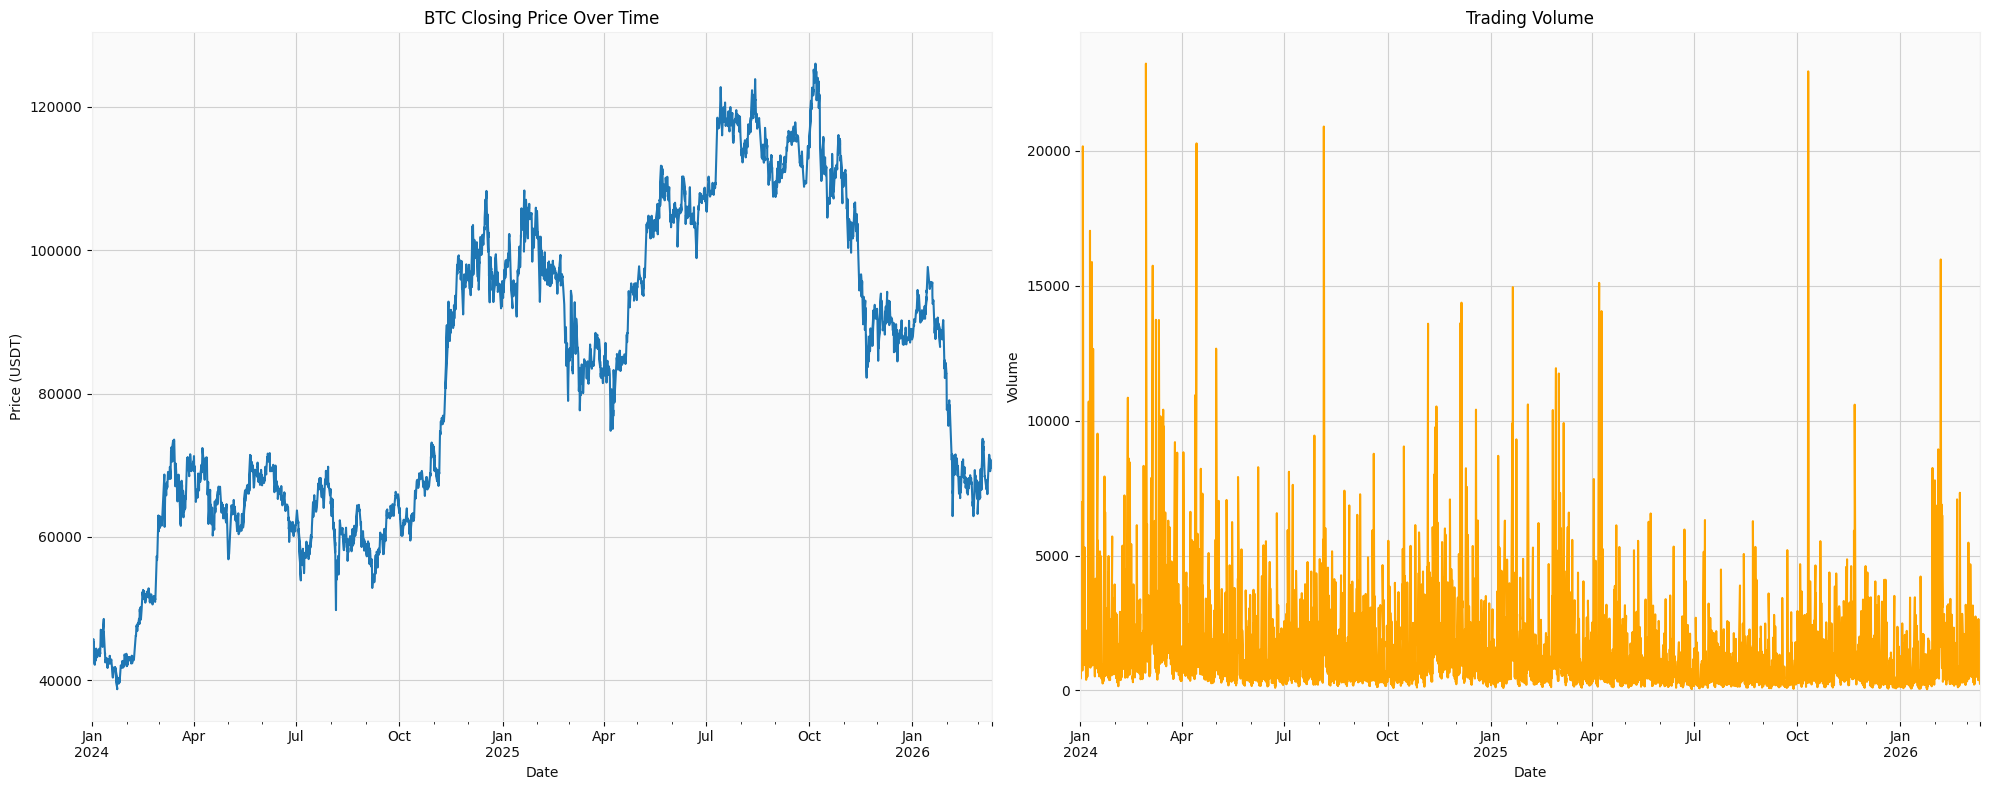

In [57]:
# --- Cell 9: Side-by-Side Price and Volume ---
plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
raw_df['Close'].plot(title='BTC Closing Price Over Time')
plt.ylabel('Price (USDT)')
plt.grid(True)

plt.subplot(1, 2, 2)
raw_df['Volume'].plot(title='Trading Volume', color='orange')
plt.ylabel('Volume')
plt.grid(True)

plt.tight_layout()
plt.show()


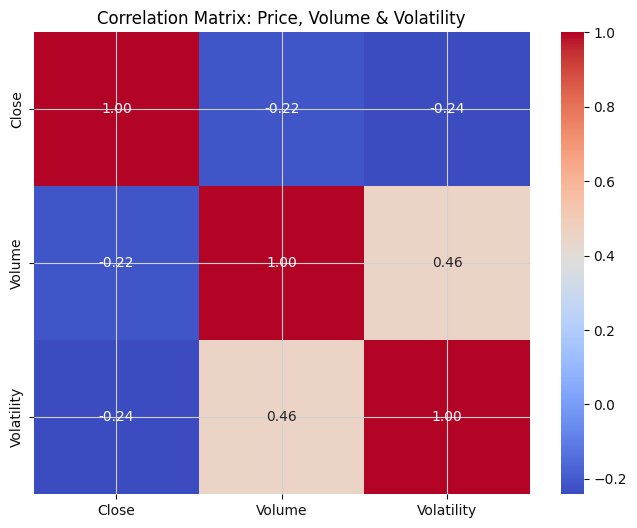


--- Interpreting the Correlations ---
               Close    Volume  Volatility
Close       1.000000 -0.215422   -0.241307
Volume     -0.215422  1.000000    0.455722
Volatility -0.241307  0.455722    1.000000


In [58]:
# --- Cell 10: Correlation Matrix ---
volatility = returns.rolling(window=24).std()
correlation_df = raw_df[['Close', 'Volume']].copy()
correlation_df['Volatility'] = volatility

corr_matrix = correlation_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Price, Volume & Volatility')
plt.show()

print("\n--- Interpreting the Correlations ---")
print(corr_matrix)

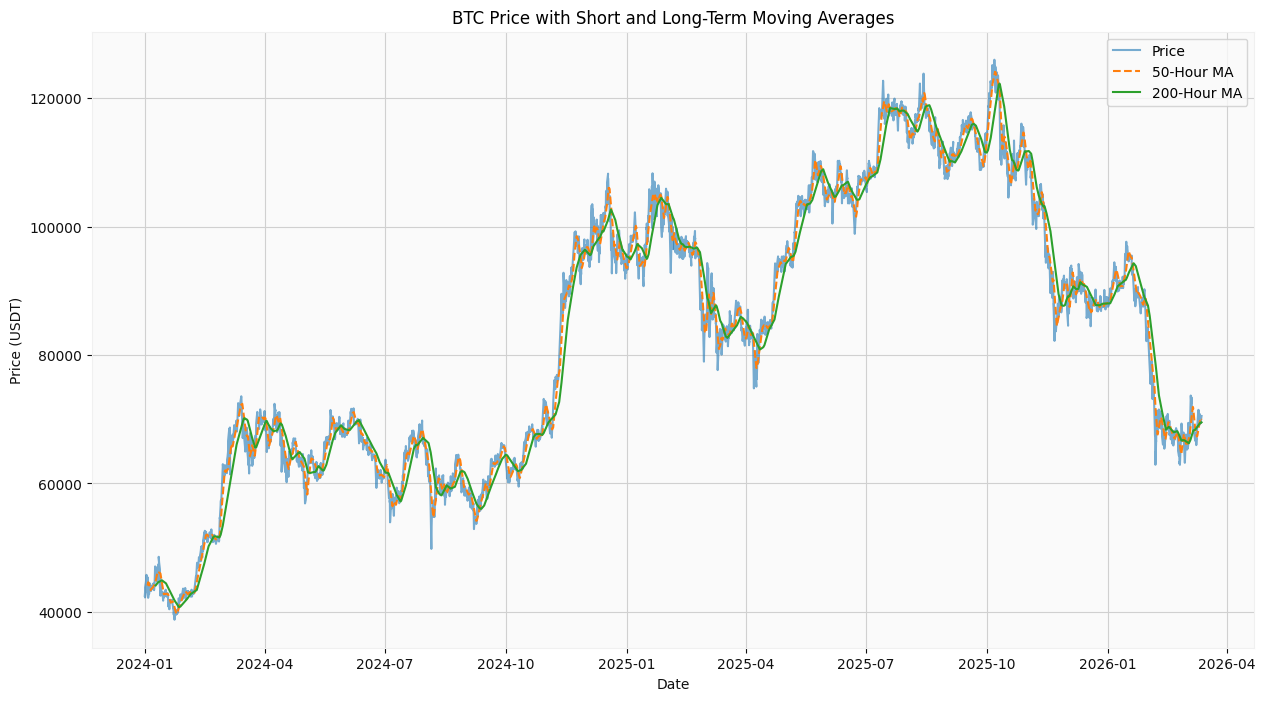

In [ ]:
# --- Cell 11: Moving Averages for Trend Analysis ---
short_window = 50
long_window = 200

# Calculate MAs just for this plot
Short_MA = raw_df['Close'].rolling(window=short_window).mean()
Long_MA = raw_df['Close'].rolling(window=long_window).mean()

plt.figure(figsize=(15, 8))
plt.plot(raw_df['Close'], label='Price', alpha=0.6)
plt.plot(Short_MA, label=f'{short_window}-Hour MA', linestyle='-')
plt.plot(Long_MA, label=f'{long_window}-Hour MA', linestyle='-')
plt.title('BTC Price with Short and Long-Term Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USDT)')
plt.legend()
plt.grid(True)
plt.show()

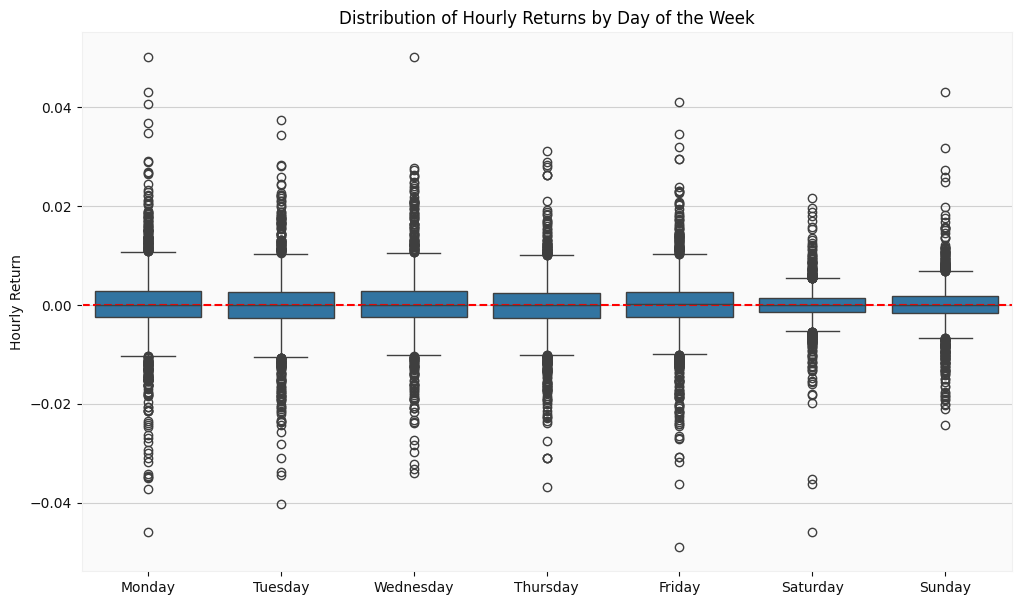

In [60]:
# --- Cell 12: Day-of-the-Week Seasonality ---
returns_df = pd.DataFrame(returns)
returns_df['Day of Week'] = returns_df.index.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(12, 7))
sns.boxplot(x='Day of Week', y='Close', data=returns_df, order=day_order)
plt.title('Distribution of Hourly Returns by Day of the Week')
plt.xlabel('')
plt.ylabel('Hourly Return')
plt.axhline(0, color='red', linestyle='--')
plt.grid(True, axis='y')
plt.show()

Part 3.1: Summary of Key Insights (Q&A)
This section consolidates our findings from the exploratory analysis into a clear question-and-answer format, providing interpretations for each discovery.

Question 1: What is the typical hourly behavior of Bitcoin? Is it very volatile?
Answer: Yes, it is a volatile asset. The Distribution of Returns histogram (Cell 7) shows us that while most hourly price changes are very small and centered around 0%, the distribution has "fat tails." This means that extreme price swings (e.g., >2-3% in a single hour) happen much more frequently than in a less volatile asset. Our model must be prepared for these sudden, large movements.

Question 2: Does volatility stay constant over time?
Answer: No, it changes significantly. The Volatility Over Time plot (Cell 8) clearly shows that volatility is "clustered." There are distinct periods of calm (small price swings) followed by chaotic periods of high volatility (large, spiky price swings). This tells us the market has different "regimes," and a successful model will need to adapt to them.

Question 3: How are the key variables (Price, Volume, and Volatility) related?
Answer: The Correlation Matrix (Cell 10) gave us crucial insights:

Volume and Volatility have a moderate positive correlation (approx. +0.46). This is our strongest finding. In simple terms: active trading days are volatile days. High trading volume is a strong indicator of large price movements.
Price and Volatility have a weak negative correlation (approx. -0.24). This suggests that volatility tends to be slightly higher when prices are lower. This may point to "panic selling" and fear during market downturns causing more erratic price action.
Question 4: Can we see clear trends in the price data?
Answer: Yes. The Moving Averages plot (Cell 11) is excellent for this. It smooths out the noise and shows the underlying direction of the market. We can visually confirm that the price goes through clear uptrends (when the price is above the long-term 200-hour average) and downtrends. The relationship between the short-term and long-term averages will be a critical feature for our model to understand momentum.

Question 5: Is there a simple "Day of the Week" pattern to trade?
Answer: It appears not. The Day-of-the-Week Boxplot (Cell 12) shows that while there are minor differences in the distribution of returns for each day, no single day shows a strong, reliable tendency to be positive or negative. This suggests that a strategy based solely on the day of the week would likely not be effective.

Part 4: Save Processed Data
This is the final step, where we save our clean data to be used in the next notebook.

In [61]:
# --- Cell 13: Save the Cleaned Data ---
output_dir = '../data/processed'
processed_data_path = os.path.join(output_dir, '01_cleaned_btc_data.csv')

print(f"Ensuring directory exists: {output_dir}")
os.makedirs(output_dir, exist_ok=True)

raw_df.to_csv(processed_data_path, index=True)

print(f"\n✅ Success! Clean data saved to: {processed_data_path}")
print("\nThis notebook is now complete and ready for commit.")

Ensuring directory exists: ../data/processed

✅ Success! Clean data saved to: ../data/processed/01_cleaned_btc_data.csv

This notebook is now complete and ready for commit.
